#### varaibles
- real gdp per capita growth - trend + cycle of real values? diff og gdp real per capita
- inflation = inflation trend + measurement errors???
- short rate = inflation trend + real rate trend 
- long rate = inflation trend + real rate trend + term trend
- inflation expectations??
- growth expextations??
- 

In [2]:
import Pkg
Pkg.activate("../")

include("../src/TCVAR/TCVAR.jl")

  Activating project at `~/projects/MacroFinanceScenarios`


Main.TCVAR

In [3]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Plots


In [4]:
df = DataFrame(XLSX.readtable("../../../data/usa_macro_data_s.xlsx", "Quarterly", infer_eltypes=true))
data_source = TimeArray(df; timestamp = :observation_date)
data_source = from(data_source, Date(1991, 10, 01))


gdp = percentchange(data_source[:A939RX0Q048SBEA], :log) .* 400
cpi = percentchange(data_source[:GDPDEF], :log) .* 400

data = merge(gdp, cpi, data_source[[:TB3MS, :GS10]])

presample_end_date = Date(1994,12,31)

presample, data = data[Date(1992,01,01):Date(2000,12,31)], data[Date(2001,01,01):Date(2024,12,31)]

display(presample)
display(data)

term =  presample[:GS10] .- presample[:TB3MS]
real_rate = presample[:TB3MS] .- presample[:GDPDEF] 

presample = merge(presample[[:A939RX0Q048SBEA, :GDPDEF]], real_rate, term)


LoadError: XLSXError: File ../../../data/usa_macro_data_s.xlsx not found.

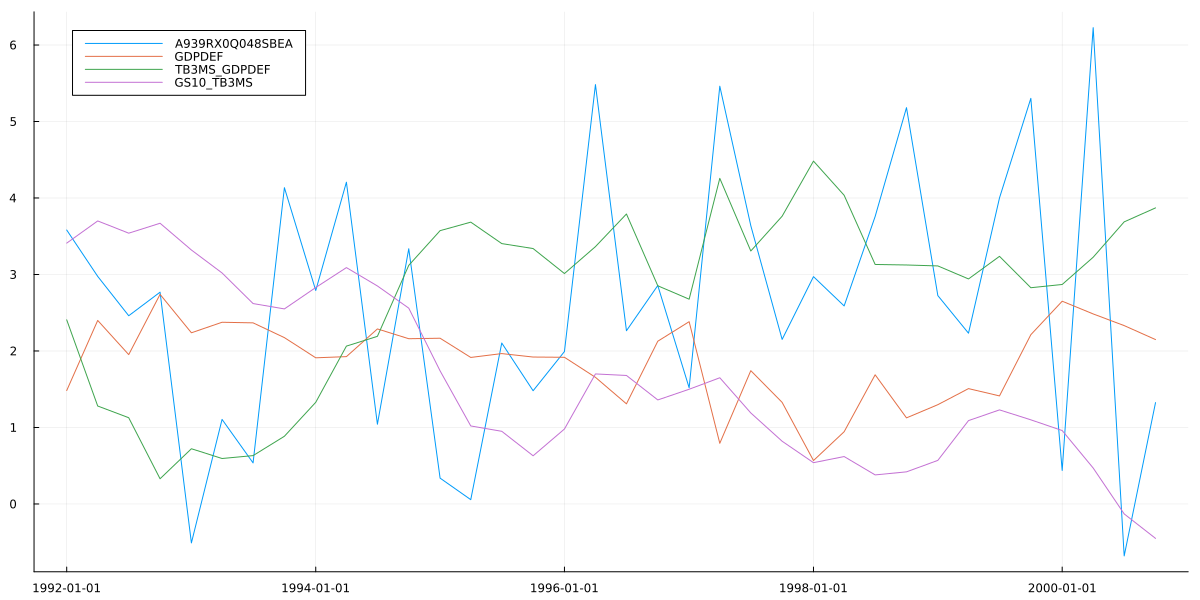

In [175]:
plot(presample; size=(1200, 600))

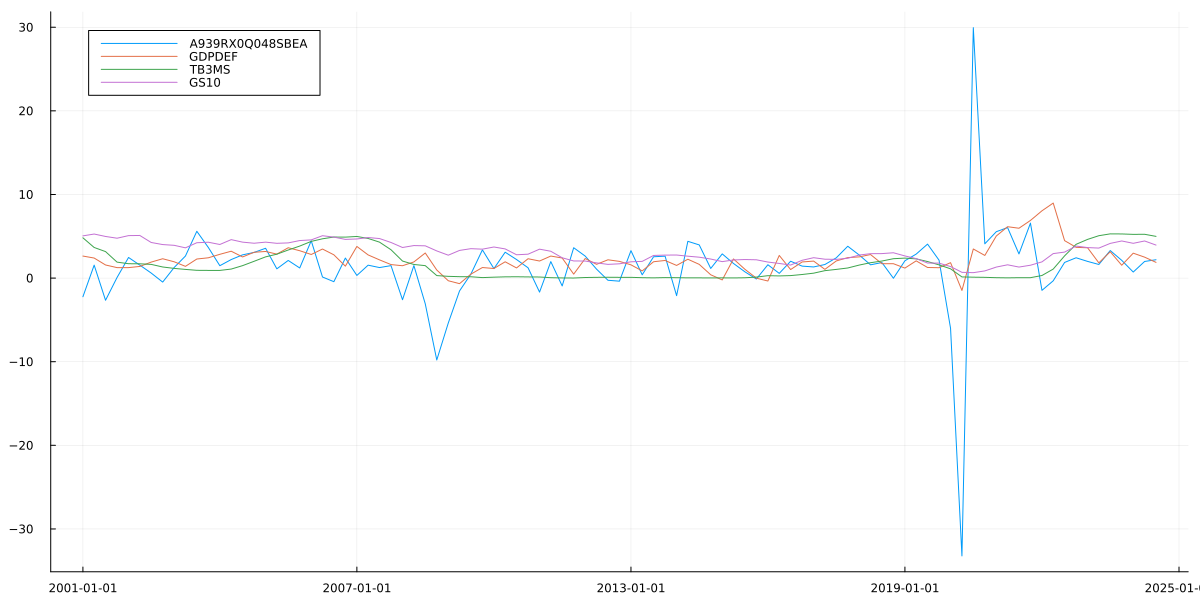

In [176]:
plot(data; size=(1200, 600))

In [177]:
presample_mean = mean(presample)
presample_mean = round.(presample_mean, digits=2)
display("presample mean")
display(presample_mean)

presample_variance = var(presample)
presample_variance = round.(presample_variance, digits=2)
display("presample variance")
display(presample_variance)
display(presample_variance .^ .5) 

"presample mean"

1×4 TimeArray{Float64, 2, Date, Matrix{Float64}} 2000-10-01 to 2000-10-01
┌────────────┬─────────────────┬────────┬──────────────┬────────────┐
│            │ A939RX0Q048SBEA │ GDPDEF │ TB3MS_GDPDEF │ GS10_TB3MS │
├────────────┼─────────────────┼────────┼──────────────┼────────────┤
│ 2000-10-01 │            2.61 │   1.88 │         2.73 │       1.64 │
└────────────┴─────────────────┴────────┴──────────────┴────────────┘

"presample variance"

1×4 TimeArray{Float64, 2, Date, Matrix{Float64}} 2000-10-01 to 2000-10-01
┌────────────┬─────────────────┬────────┬──────────────┬────────────┐
│            │ A939RX0Q048SBEA │ GDPDEF │ TB3MS_GDPDEF │ GS10_TB3MS │
├────────────┼─────────────────┼────────┼──────────────┼────────────┤
│ 2000-10-01 │            3.02 │   0.28 │          1.3 │       1.35 │
└────────────┴─────────────────┴────────┴──────────────┴────────────┘

1×4 TimeArray{Float64, 2, Date, Matrix{Float64}} 2000-10-01 to 2000-10-01
┌────────────┬─────────────────┬─────────┬──────────────┬────────────┐
│            │ A939RX0Q048SBEA │ GDPDEF  │ TB3MS_GDPDEF │ GS10_TB3MS │
├────────────┼─────────────────┼─────────┼──────────────┼────────────┤
│ 2000-10-01 │         1.73781 │ 0.52915 │      1.14018 │     1.1619 │
└────────────┴─────────────────┴─────────┴──────────────┴────────────┘

In [178]:
n = 4 #number of observatin variables

priors = (
        initial_trend_mean = values(presample_mean)[1,:],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,n)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2.5, 5, 5, 5] ./ 400),
        cycle_coeff_mean = zeros(n, n),
        cycle_coeff_shrinkage_param = .2,
        cycle_covariance_mean = diagm(values(presample_variance)[1,:]), #diagm(presample_variance), 
        cycle_covariance_df = n+2
        )


(initial_trend_mean = [2.61, 1.88, 2.73, 1.64], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 0 0; 0 1 0 0; 0 0 1 0; 0 0 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.00625 0.0 0.0 0.0; 0.0 0.0125 0.0 0.0; 0.0 0.0 0.0125 0.0; 0.0 0.0 0.0 0.0125], cycle_coeff_mean = [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0], cycle_coeff_shrinkage_param = 0.2, cycle_covariance_mean = [3.02 0.0 0.0 0.0; 0.0 0.28 0.0 0.0; 0.0 0.0 1.3 0.0; 0.0 0.0 0.0 1.35], cycle_covariance_df = 6)

In [179]:
priors.cycle_covariance_mean

4×4 Matrix{Float64}:
 3.02  0.0   0.0  0.0
 0.0   0.28  0.0  0.0
 0.0   0.0   1.3  0.0
 0.0   0.0   0.0  1.35

In [180]:
observation_tend_mapping  = [1 0 0 0 
                             0 1 0 0 
                             0 1 1 0 
                             0 1 1 1 ]

trend_states_samples, cycle_states_samples, trend_covariance_samples, betas_samples, sigmas_samples = TCVAR.gibs_sampler(values(data), observation_tend_mapping, priors; burnin = 50_000, n_samples = 50_000, thin=25)

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.68)  
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95) 

([-3.46119563536197 0.5357977516394746 1.0065976671269703 -0.10339658246166072; 0.24630153849895703 0.32172478778538977 -0.08517937403409687 0.18790071097475408; … ; 0.18120877245245023 -0.007455571070577188 1.7553867037086666 0.34216243436432353; 0.37218628563359923 -0.6193071533915347 1.5261371353800763 -0.12589232264151776], [-4.539831369472496 -0.8210807949929632 -0.7232110668105024 -2.0692583669155757; -0.8630136539415055 -1.0055615236243356 -1.8351293547570602 -1.7743540762249823; … ; -0.9719834076602402 -1.8183721762360063 -1.1586508742333792 -2.877003647381581; -0.8716998172175664 -2.450602348457659 -1.5429420587087752 -3.54499021931393], [-1.8909089881573922 1.9093467010127014 2.7188998900028962 2.0223277967942694; 1.325780590282838 1.7133772008144714 1.6095521477723516 2.321184634434643; … ; 1.335064866623295 2.122736324059271 4.324817987451939 2.9265857977499783; 1.5836304308850537 1.5332108576847636 4.103951214667743 2.493052570326538])

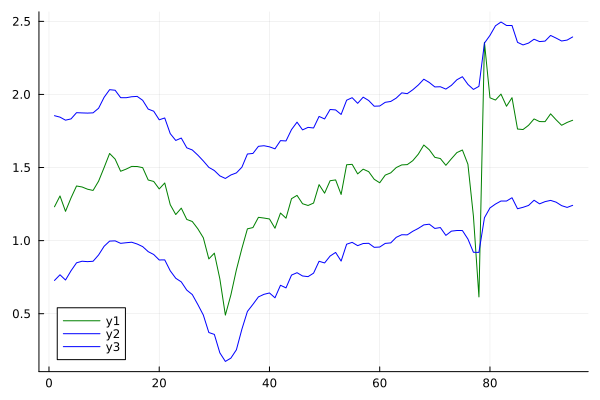

In [181]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

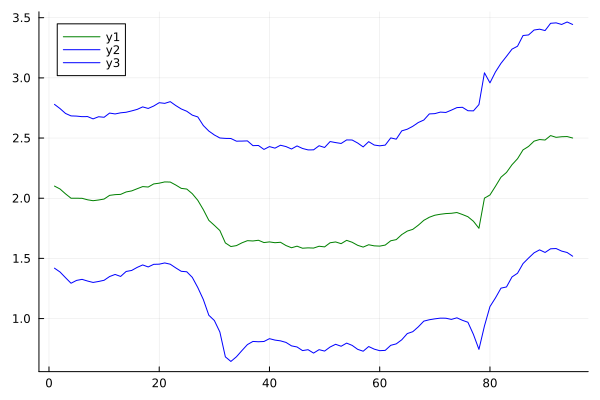

In [201]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

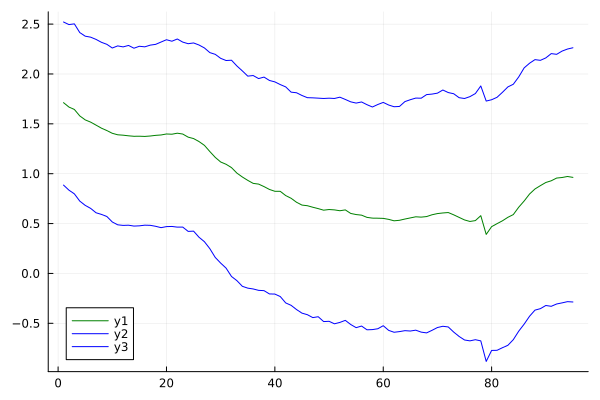

In [183]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

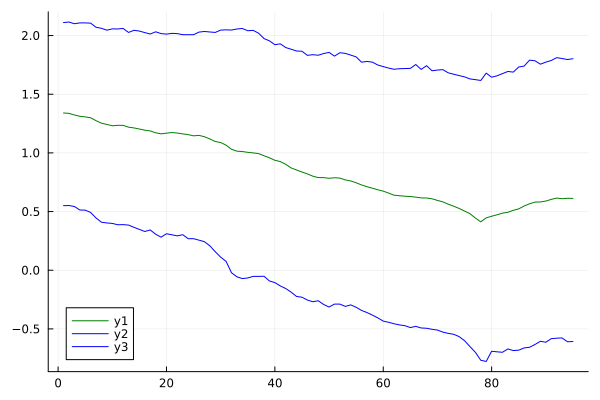

In [184]:
st = 4
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

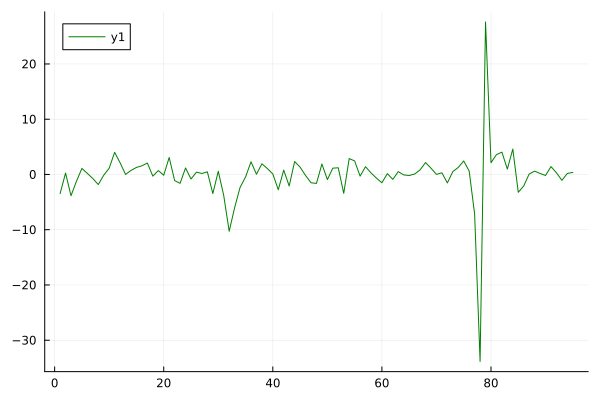

In [185]:
st=1
plot(cycle_states_mean[:,st], color="green" )

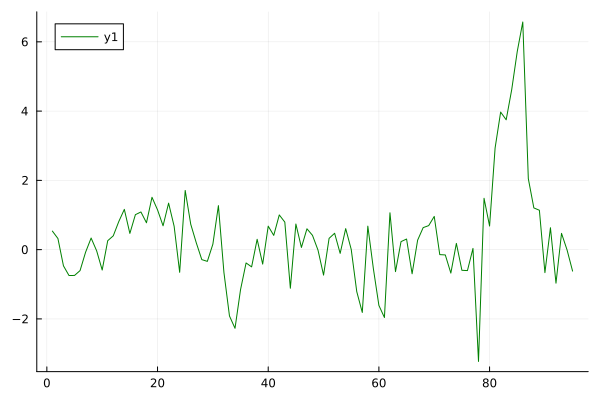

In [186]:
st=2
plot(cycle_states_mean[:,st], color="green" )

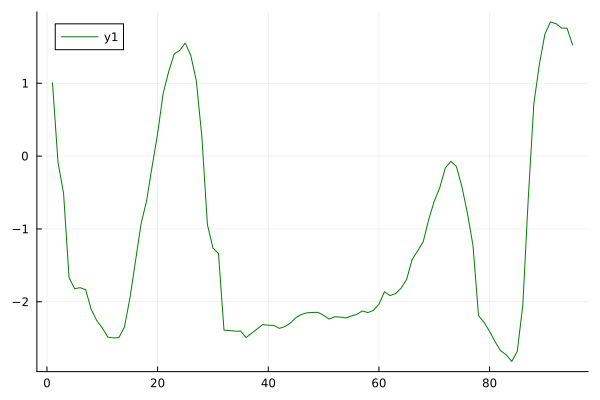

In [187]:
st=3
plot(cycle_states_mean[:,st], color="green" )

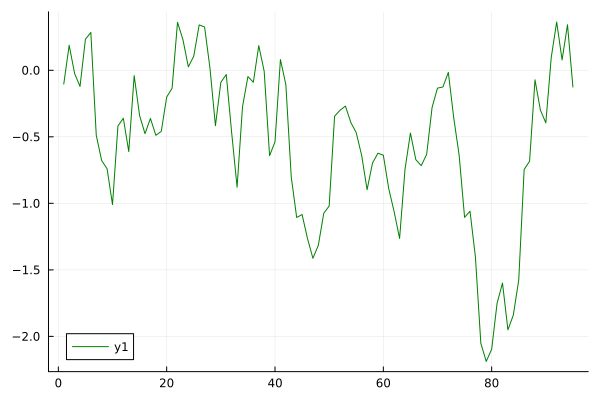

In [188]:
st=4
plot(cycle_states_mean[:,st], color="green" )

In [202]:
summarystats(trend_covariance_samples)

Summary Statistics
  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

         Στ1    0.5774    3.1105    0.5565    133.7520    30.0441    1.0112    ⋯
         Στ2    0.0627    0.3649    0.0600    148.2061    32.5484    1.0080    ⋯
         Στ3   -0.0641    0.3979    0.0635    141.2625    34.1785    1.0054    ⋯
         Στ4    0.0151    0.1219    0.0126    509.2097    43.6460    1.0063    ⋯
         Στ5    0.0627    0.3649    0.0600    148.2061    32.5484    1.0080    ⋯
         Στ6    0.0299    0.0718    0.0085    179.3893    51.8648    1.0071    ⋯
         Στ7   -0.0045    0.0766    0.0098    129.2377    34.8794    1.0086    ⋯
         Στ8    0.0046    0.0239    0.0016    623.7888   147.3960    1.0033    ⋯
         Στ9   -0.0641    0.3979    0.0635    141.2625    34.1785    1.0054    ⋯
        Στ10   -0.0045    0.0766    0.0098    129.2377    34.8794    1.0086    ⋯
        

In [203]:
summarystats(betas_samples)

Summary Statistics
  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

         Σc1   -0.1870    0.1133    0.0032   1496.8591    649.9315    1.0011   ⋯
         Σc2   -0.2485    0.4326    0.0105   1751.7742   1931.2604    1.0015   ⋯
         Σc3   -0.1201    0.3979    0.0089   2018.9160   2087.9145    0.9999   ⋯
         Σc4   -0.1794    0.6782    0.0164   1717.4184   1811.4656    1.0007   ⋯
         Σc5   -0.0203    0.0506    0.0014   1738.8761    748.4267    0.9999   ⋯
         Σc6    0.6630    0.1838    0.0044   1679.9614   1615.3817    0.9996   ⋯
         Σc7   -0.0530    0.1707    0.0039   1894.6625   1912.2863    1.0001   ⋯
         Σc8   -0.1166    0.2415    0.0053   2068.5777   2003.4620    1.0013   ⋯
         Σc9    0.0011    0.0416    0.0010   1667.1148   1793.2580    1.0009   ⋯
        Σc10    0.0610    0.1288    0.0028   2137.1990   1655.2541    1.0016   ⋯
        

In [214]:
summarystats(sigmas_samples)

Summary Statistics
  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

         Σc1   25.3619    5.5491    0.9027    101.8775     34.9868    1.0107   ⋯
         Σc2    2.5871    1.3240    0.0941    245.5148     87.6706    1.0029   ⋯
         Σc3    0.4595    0.9118    0.0221   1525.3789   1849.0576    1.0006   ⋯
         Σc4    0.1033    1.6156    0.0362   1993.2407   1808.2018    0.9997   ⋯
         Σc5    2.5871    1.3240    0.0941    245.5148     87.6706    1.0029   ⋯
         Σc6    4.4351    6.9225    0.1617    371.2880    279.7834    1.0078   ⋯
         Σc7    1.5834    4.5793    0.1056   1449.8422   2009.2768    0.9997   ⋯
         Σc8    2.5583    5.8802    0.1417   1610.0934   1724.1660    1.0005   ⋯
         Σc9    0.4595    0.9118    0.0221   1525.3789   1849.0576    1.0006   ⋯
        Σc10    1.5834    4.5793    0.1056   1449.8422   2009.2768    0.9997   ⋯
        

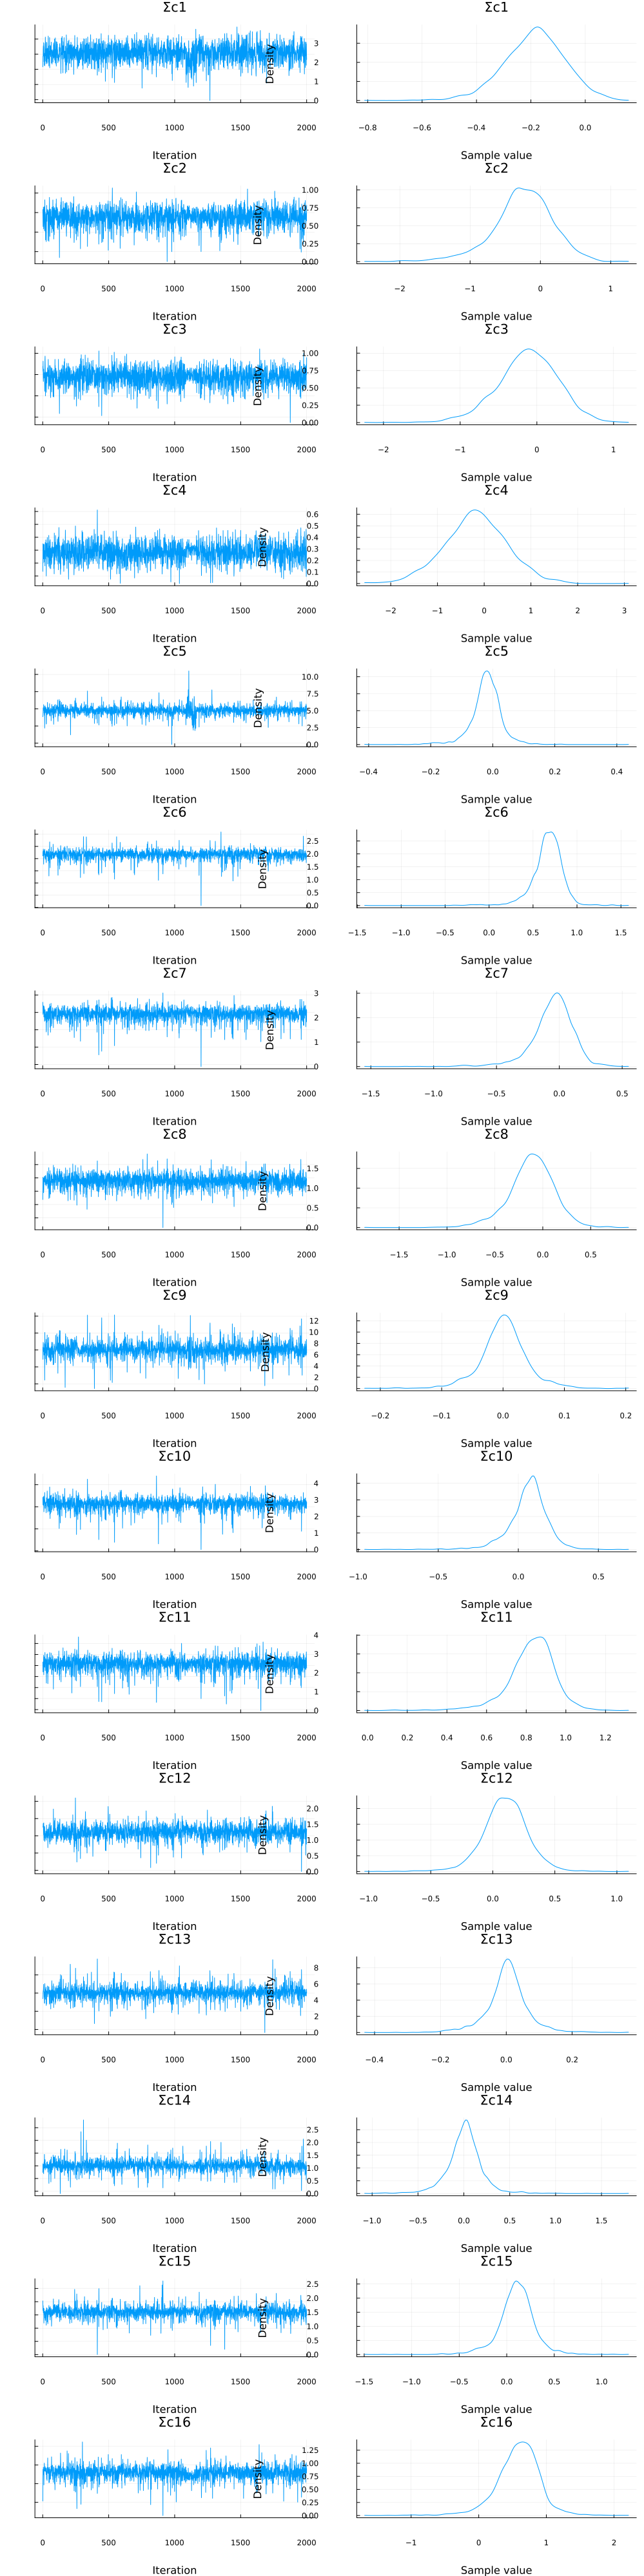

In [205]:
plot(betas_samples)

In [219]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*1)
display(β)

Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, 4, 4)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

4×4 Matrix{Float64}:
 25.3619    2.58714  0.459486  0.103271
  2.58714   4.43507  1.58339   2.55829
  0.459486  1.58339  2.46182   1.01603
  0.103271  2.55829  1.01603   7.53751

4×4 Matrix{Float64}:
 -0.187043  -0.0203009  0.00113859  0.00329465
 -0.248549   0.663039   0.0610337   0.00707307
 -0.12013   -0.0529868  0.825665    0.103598
 -0.179362  -0.116596   0.100388    0.580929

4×4 Matrix{Float64}:
  1.0        0.476807  -0.493455   0.14815
  0.476807   1.0       -0.151855   0.199687
 -0.493455  -0.151855   1.0        0.0100688
  0.14815    0.199687   0.0100688  1.0

4-element Vector{Float64}:
 0.7598691703036231
 0.17298934711122016
 0.17104752790863254
 0.13453555279441382

In [220]:
display(diag(Σc) .^ .5)

display(diag(Στ) .^ .5)

4-element Vector{Float64}:
 5.0360599404661315
 2.105960566065142
 1.5690196281109023
 2.745451997341438

4-element Vector{Float64}:
 0.7598691703036231
 0.17298934711122016
 0.17104752790863254
 0.13453555279441382

In [221]:
model = tc_var(observation_tend_mapping, β, Στ, Σc, priors.initial_trend_mean, priors.initial_cycle_mean, priors.initial_trend_covariance, priors.cycle_covariance_mean)

initial_states = [trend_states_mean[end,:]; cycle_states_mean[end,:]]

n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = sample(model, initial_states, T)
end


UndefVarError: UndefVarError: `sample` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name may be made accessible by importing AliasTables in the current active module Main
Hint: a global variable of this name also exists in StatsBase.
Hint: a global variable of this name may be made accessible by importing AbstractMCMC in the current active module Main
Hint: a global variable of this name may be made accessible by importing MCMCChains in the current active module Main

In [209]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `cum_returns_in_periods` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [210]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `print_scenarios_summary` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

In [211]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95) 

UndefVarError: UndefVarError: `carter_kohn_sampler` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

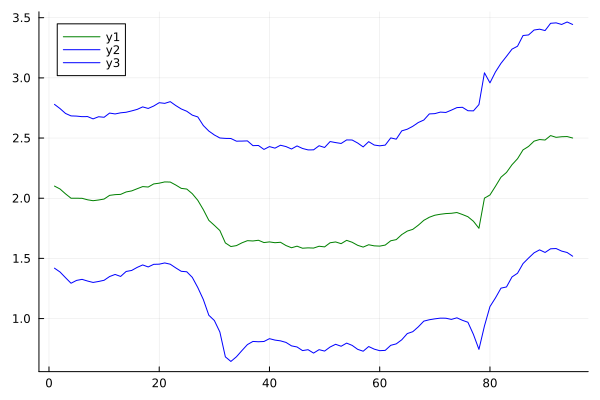

In [212]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

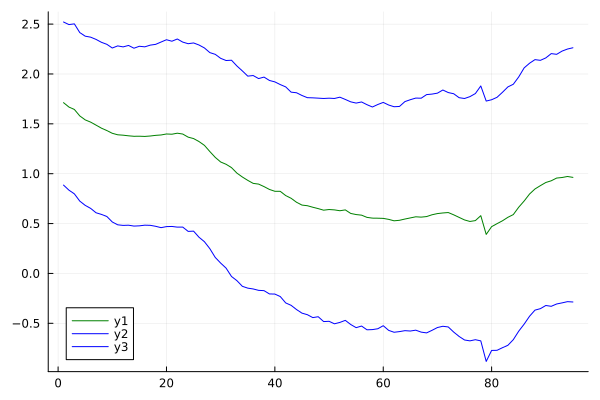

In [213]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")